In [6]:
df = pd.read_csv("../data/medical_insurance.csv")

In [17]:
df.shape

(1337, 7)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


In [12]:
df.describe()


,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df = df.drop_duplicates()


In [19]:
df.duplicated().sum()

0

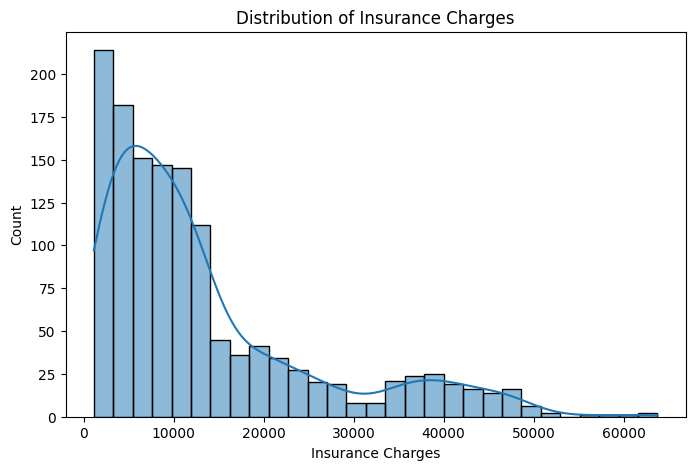

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")

plt.xlabel("Insurance Charges")

plt.ylabel("Count")

plt.show()

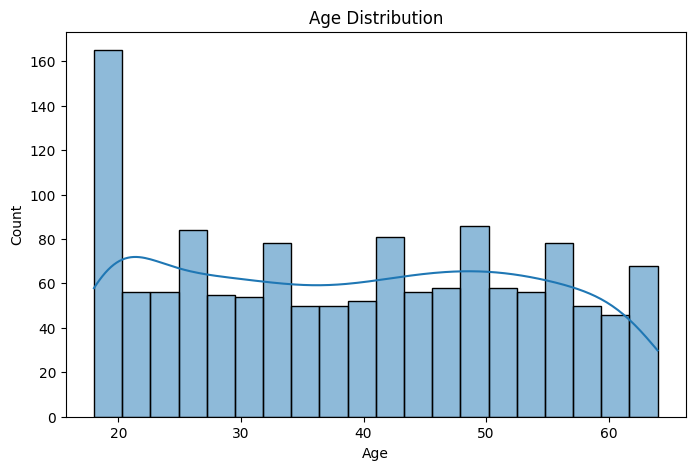

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

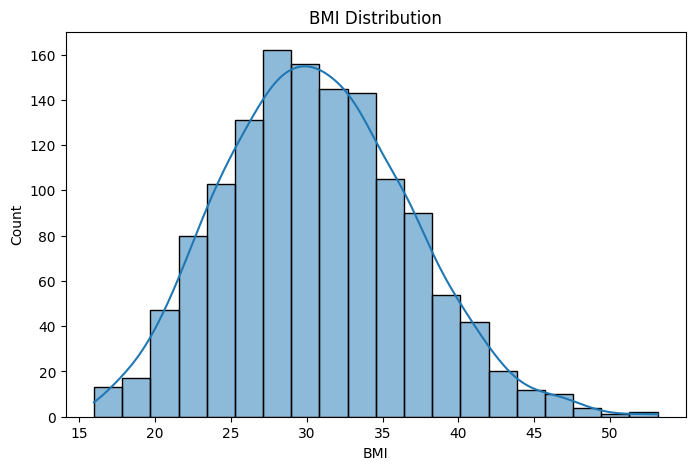

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["bmi"], bins=20, kde=True)

plt.title("BMI Distribution")

plt.xlabel("BMI")

plt.ylabel("Count")

plt.show()

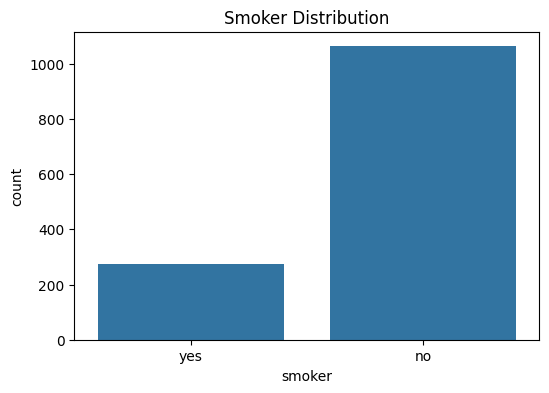

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x="smoker", data=df)

plt.title("Smoker Distribution")

plt.show()

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


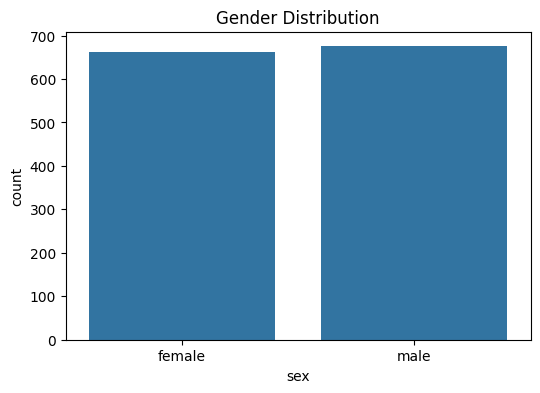

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")

plt.show()

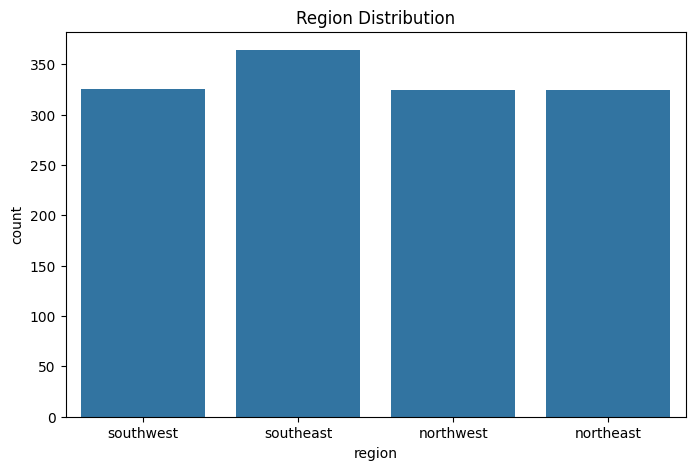

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x="region", data=df)

plt.title("Region Distribution")

plt.show()

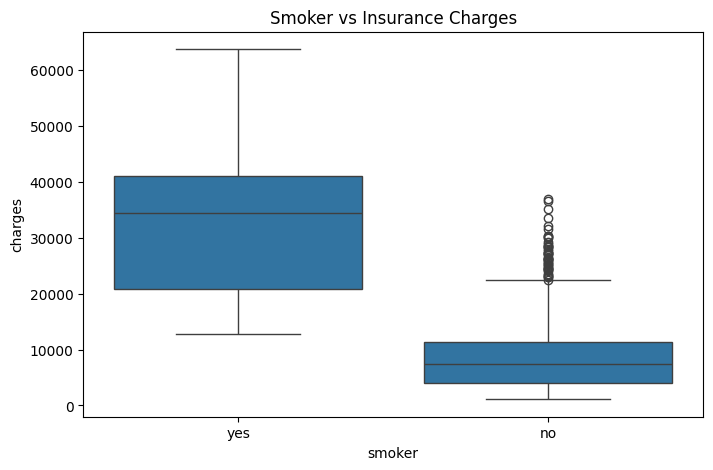

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Smoker vs Insurance Charges")

plt.show()

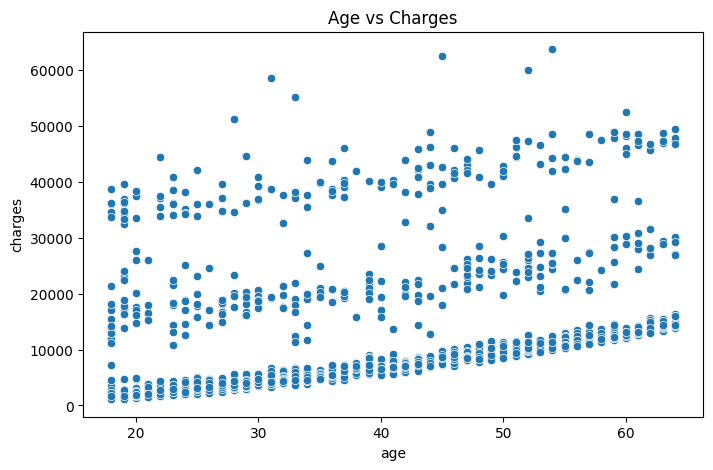

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="age", y="charges", data=df)

plt.title("Age vs Charges")

plt.show()

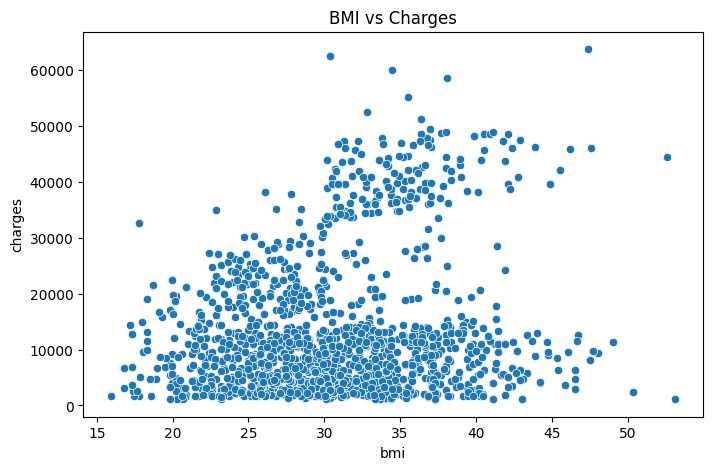

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="bmi", y="charges", data=df)

plt.title("BMI vs Charges")

plt.show()

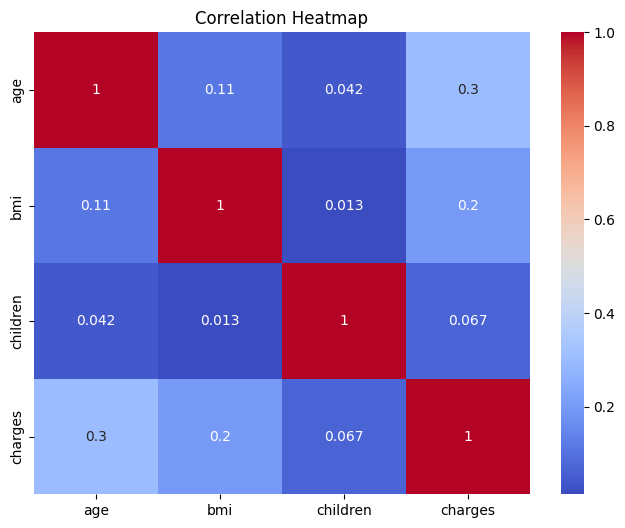

In [29]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
def bmi_category(bmi):

    if bmi < 18.5:
        return "Underweight"

    elif bmi < 25:
        return "Normal"

    elif bmi < 30:
        return "Overweight"

    else:
        return "Obese"

df["bmi_category"] = df["bmi"].apply(bmi_category)

In [31]:
df[["bmi", "bmi_category"]].head()

,bmi,bmi_category
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight


In [37]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,45,60,100],
    labels=["Young","Adult","Middle","Senior"],
    include_lowest=True
)

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [33]:
df[["age", "age_group"]].head()

,age,age_group
0,19,Young
1,18,NaN
2,28,Young
3,33,Adult
4,32,Adult


In [34]:
df["family_size"] = df["children"] + 1

In [35]:
df[["children", "family_size"]].head()


,children,family_size
0,0,1
1,1,2
2,3,4
3,0,1
4,0,1


In [38]:
df.head()


,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,family_size
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,Young,1
1,18,male,33.770,1,no,southeast,1725.55230,Obese,Young,2
2,28,male,33.000,3,no,southeast,4449.46200,Obese,Young,4
3,33,male,22.705,0,no,northwest,21984.47061,Normal,Adult,1
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,Adult,1


In [39]:
X = df.drop("charges", axis=1)

y = df["charges"]

In [40]:
X.head()

,age,sex,bmi,children,smoker,region,bmi_category,age_group,family_size
0,19,female,27.900,0,yes,southwest,Overweight,Young,1
1,18,male,33.770,1,no,southeast,Obese,Young,2
2,28,male,33.000,3,no,southeast,Obese,Young,4
3,33,male,22.705,0,no,northwest,Normal,Adult,1
4,32,male,28.880,0,no,northwest,Overweight,Adult,1


In [41]:
y.head

<bound method NDFrame.head of 0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1337, dtype: float64>

In [42]:
num_cols = [
    "age",
    "bmi",
    "children",
    "family_size"
]

cat_cols = [
    "sex",
    "smoker",
    "region",
    "bmi_category",
    "age_group"
]

In [43]:
print(num_cols)

print(cat_cols)

['age', 'bmi', 'children', 'family_size']
['sex', 'smoker', 'region', 'bmi_category', 'age_group']


In [44]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [45]:
print(X.head())
print(y.head())

   age     sex     bmi  children smoker     region bmi_category age_group  \
0   19  female  27.900         0    yes  southwest   Overweight     Young   
1   18    male  33.770         1     no  southeast        Obese     Young   
2   28    male  33.000         3     no  southeast        Obese     Young   
3   33    male  22.705         0     no  northwest       Normal     Adult   
4   32    male  28.880         0     no  northwest   Overweight     Adult   

   family_size  
0            1  
1            2  
2            4  
3            1  
4            1  
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1069, 9)
Testing Data: (268, 9)


In [48]:
num_cols = ["age", "bmi", "children", "family_size"]

cat_cols = ["sex", "smoker", "region", "bmi_category", "age_group"]

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [52]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", pca),
    ("model", model)
])

In [53]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [54]:
y_pred = pipeline.predict(X_test)

In [55]:
print(y_pred[:5])

[ 8682.88899348  4795.24193577 15054.89932831 32402.72867963
  9173.69125647]


In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [57]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 4207.389887270049
RMSE : 5990.999394103721
R2 Score : 0.8046754324683215


In [58]:
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

print("Adjusted R2 :", adjusted_r2)

Adjusted R2 : 0.797861784763728


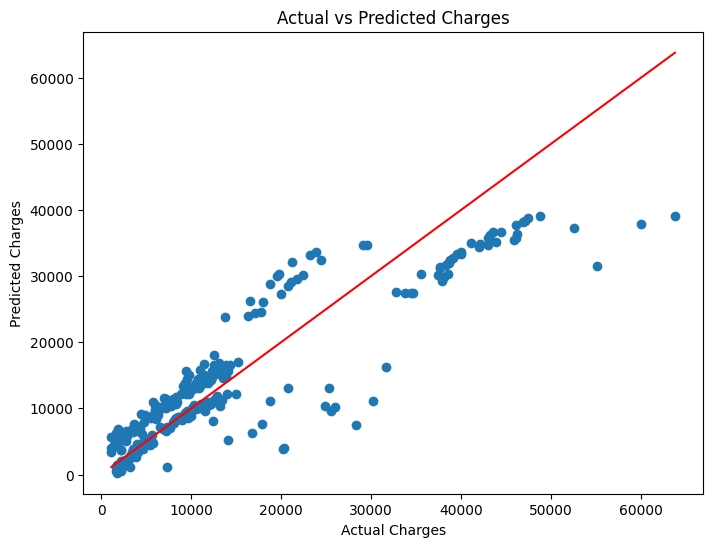

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

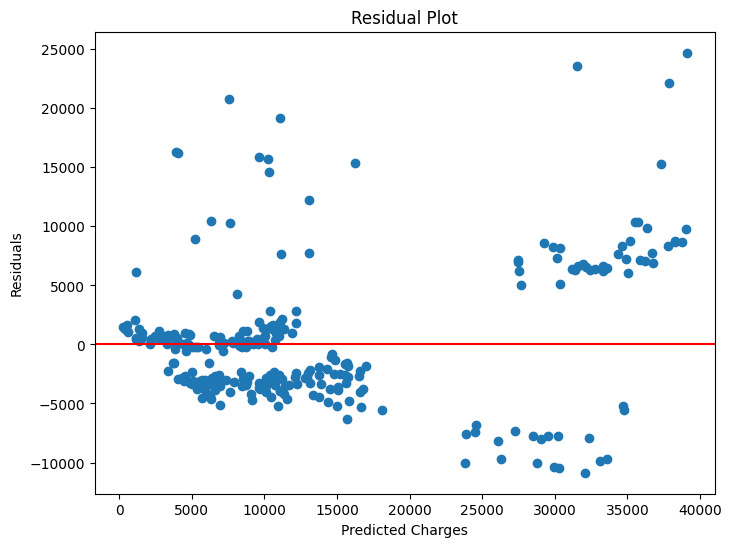

In [60]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()